In [1]:
import numpy as np
from pathlib import Path
import pandas as pd

In [2]:
saved_dir = Path(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD")

train_dfs = pd.read_pickle(saved_dir / "train_dfs.pkl")
test_dfs = pd.read_pickle(saved_dir / "test_dfs.pkl")

print("Reloaded train_dfs and test_dfs from saved_data/")
print("Train dfs:", len(train_dfs))
print("Test dfs:", len(test_dfs))
print("Train sizes:", [len(df) for df in train_dfs])
print("Test sizes:", [len(df) for df in test_dfs])

Reloaded train_dfs and test_dfs from saved_data/
Train dfs: 28
Test dfs: 28
Train sizes: [65010, 63341, 55726, 54014, 33464, 32452, 49539, 49505, 170718, 168763, 116716, 114204, 170841, 165956, 54322, 53784, 79703, 77806, 112684, 110737, 106590, 104997, 140756, 137805, 124842, 122961, 2393018, 850900]
Test sizes: [16252, 15835, 13931, 13503, 8365, 8113, 12384, 12376, 42679, 42190, 29178, 28550, 42710, 41488, 13580, 13446, 19925, 19451, 28171, 27684, 26647, 26249, 35189, 34451, 31210, 30740, 598254, 212724]


In [3]:
def data_to_uint8_array(data):
    if isinstance(data, bytes):
        arr = np.frombuffer(data, dtype=np.uint8)
    elif isinstance(data, str):
        s = data.strip()
        if s.startswith(("0x", "0X")):
            s = s[2:]
        if any(ch in s for ch in (" ", "-", ":", ",")):
            parts = [tok for tok in s.replace("-", " ").replace(":", " ").replace(",", " ").split() if tok]
            if all(len(tok) == 2 for tok in parts):
                arr = np.array([int(tok, 16) for tok in parts], dtype=np.uint8)
            else:
                arr = np.frombuffer(bytes.fromhex("".join(parts)), dtype=np.uint8)
        else:
            arr = np.frombuffer(bytes.fromhex(s), dtype=np.uint8)
    elif isinstance(data, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(data, dtype=np.uint8).flatten()
    elif isinstance(data, int):
        arr = np.frombuffer(data.to_bytes(8, byteorder="big", signed=False), dtype=np.uint8)
    else:
        raise TypeError(f"Unsupported Data type: {type(data)}")

    if arr.size < 8:
        arr = np.pad(arr, (0, 8 - arr.size), constant_values=0)
    elif arr.size > 8:
        arr = arr[:8]

    return arr

def sliding_windows_from_dfs(dfs, data_col="Data", window_size=32, step=2):
    windows = []
    next_values = []

    for df in dfs:
        values = df[data_col].tolist()
        byte_rows = np.stack([data_to_uint8_array(value) for value in values])

        for start in range(0, len(byte_rows) - window_size, step):
            end = start + window_size
            windows.append(byte_rows[start:end])
            next_values.append(byte_rows[end])

    return np.array(windows, dtype=np.uint8), np.array(next_values, dtype=np.uint8)

train_windows, train_next = sliding_windows_from_dfs(train_dfs, data_col="Data")
test_windows, test_next = sliding_windows_from_dfs(test_dfs, data_col="Data")

print("train_windows shape:", train_windows[0])
print("test_windows shape:", test_windows[0])

train_windows shape: [[  0   0   0   0   0  12   0  10]
 [137  47  96  11  10   1   0 128]
 [ 78 224   0   0  64   0   0   0]
 [  0 126  32  16   2   0  40 240]
 [  2 119   4  96  95   3 154   0]
 [  4  64   4 125  31 192  21  98]
 [144   0  65  31  64  63 109  96]
 [  1 244  15 199 203  31  82 154]
 [  0   6 120   0  12   2 215 208]
 [  0 242  32 252 144 124 141 217]
 [ 96   0   0   0   0   0   0   0]
 [  0   8   4  19 234  17 244 206]
 [  0  16 249 164 193  46  16 160]
 [ 32  82  86   2   8   9 118 214]
 [123  85  31 186 210  83 105  46]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  3  31   3  27   3  34   3  33]
 [ 32  19  64   0   0   1 136 128]
 [137  47  96  11  10   1   0 128]
 [  0   0   0   0   0   0  24  64]
 [  0   0   0   0   0   0   0   0]
 [ 10 119   4  96  94   3 154   0]
 [  0   6 112   0  12  66 215 208]
 [  0  16 250  36 193  46  16 160]
 [  0   0  18 128   0   0   0   0]
 [144   0  65  31  64  63  79  96]
 [  0  32  40  64   0   0 128  64]

In [4]:
def sliding_windows_id_onehot_sums(dfs, id_onehot_col="ID_onehot", window_size=32, step=2):
    window_sums = []

    for df in dfs:
        if id_onehot_col not in df.columns:
            raise ValueError(f"Column {id_onehot_col!r} not found in DataFrame")

        id_onehot_arr = np.stack(df[id_onehot_col].tolist())

        if id_onehot_arr.ndim != 3 or id_onehot_arr.shape[1:] != (22, 8):
            raise ValueError(
                f"Expected {id_onehot_col} items to have shape (22, 8), "
                f"but got {id_onehot_arr.shape[1:]} from one DataFrame"
            )

        for start in range(0, len(id_onehot_arr) - window_size, step):
            window = id_onehot_arr[start:start + window_size]
            window_sums.append(window.sum(axis=0, dtype=np.uint16))

    return np.array(window_sums, dtype=np.uint16)


train_id_onehot_sums = sliding_windows_id_onehot_sums(train_dfs)
test_id_onehot_sums = sliding_windows_id_onehot_sums(test_dfs)



In [5]:
print("train_id_onehot_sums shape:", train_id_onehot_sums[0])
print("test_id_onehot_sums shape:", test_id_onehot_sums[0])

train_id_onehot_sums shape: [[ 0  0 14  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  7]
 [ 0 14  0  0  0  0  7  0]
 [ 0  0  0  0  0  0  7 14]
 [ 0  0  7  0  0  0  0  7]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0 14  0  0  0  7  0]
 [ 7  0 14  0  0  0  0  0]
 [ 0  0  7  7  7  0  0  7]
 [ 7  0  0  0  0  0  0  0]
 [ 7  0  7  0  0  0  0 14]
 [ 0  7  0  0  0  0  7  7]
 [ 0  0  0  0  0  0  0  7]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]
test_id_onehot_sums shape: [[ 0  7 14  0  0  7  0  0]
 [ 0  7  0  0  0  7  0  7]
 [ 0  7  0  0  0  0  7  0]
 [ 0  0  0  7  0  0  7 14]
 [ 0  0  7  0  0  0  7  0]
 [ 0  7  0  0  0  0  0  0]
 [ 0  0  7  0  0  0  7  0]
 [ 7  0 14  0  0  0  0  0]
 [ 0  0  0  0  7  0  0  0]
 [ 7  0  0  0  0  0  0  0]
 [ 7  0 14  0  0  0  0 14]
 [ 0  7  7  0  0  0  7  0]
 [ 0  0  0  0  0  0  0  7]

In [6]:
train_windows_combined = np.concatenate(
    [train_windows.astype(np.uint16), train_id_onehot_sums.astype(np.uint16)], axis=1
)
test_windows_combined = np.concatenate(
    [test_windows.astype(np.uint16), test_id_onehot_sums.astype(np.uint16)], axis=1
)

print("train_windows_combined shape:", train_windows_combined.shape)
print("test_windows_combined shape:", test_windows_combined.shape)

train_windows_combined shape: (2890134, 54, 8)
test_windows_combined shape: (722196, 54, 8)


In [7]:
train_windows_combined[0]

array([[  0,   0,   0,   0,   0,  12,   0,  10],
       [137,  47,  96,  11,  10,   1,   0, 128],
       [ 78, 224,   0,   0,  64,   0,   0,   0],
       [  0, 126,  32,  16,   2,   0,  40, 240],
       [  2, 119,   4,  96,  95,   3, 154,   0],
       [  4,  64,   4, 125,  31, 192,  21,  98],
       [144,   0,  65,  31,  64,  63, 109,  96],
       [  1, 244,  15, 199, 203,  31,  82, 154],
       [  0,   6, 120,   0,  12,   2, 215, 208],
       [  0, 242,  32, 252, 144, 124, 141, 217],
       [ 96,   0,   0,   0,   0,   0,   0,   0],
       [  0,   8,   4,  19, 234,  17, 244, 206],
       [  0,  16, 249, 164, 193,  46,  16, 160],
       [ 32,  82,  86,   2,   8,   9, 118, 214],
       [123,  85,  31, 186, 210,  83, 105,  46],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [  3,  31,   3,  27,   3,  34,   3,  33],
       [ 32,  19,  64,   0,   0,   1, 136, 128],
       [137,  47,  96,  11,  10,   1,   0, 128],
       [  0,   0,   

In [8]:
def sliding_windows_attack_labels(dfs, attack_col="Attack", window_size=32, step=2):
    windows_labels = []
    
    for df in dfs:
        attacks = df[attack_col].tolist()
        
        for start in range(0, len(attacks) - window_size, step):
            window_slice = attacks[start:start + window_size]
            
            # If 'T' is in the window, label is 'T', otherwise 'R'
            label = 'T' if 'T' in window_slice else 'R'
            windows_labels.append(label)
    
    return np.array(windows_labels, dtype=object)

attack_labels_train = sliding_windows_attack_labels(train_dfs)
attack_labels_test = sliding_windows_attack_labels(test_dfs)

print("attack_labels_train shape:", attack_labels_train.shape)
print("attack_labels_test shape:", attack_labels_test.shape)
print("Sample labels (first 20):", attack_labels_train[:20])

attack_labels_train shape: (2890134,)
attack_labels_test shape: (722196,)
Sample labels (first 20): ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


In [9]:
windows = train_windows_combined
windows_test = test_windows_combined
windowed_labels = attack_labels_train
windowed_labels_test = attack_labels_test

In [10]:
t_positions = np.flatnonzero(windowed_labels == 'T')
print(f"Found {t_positions.size} 'T' labels in windowed_labels")
if t_positions.size:
    print("First positions:", t_positions[:20].tolist())

Found 703876 'T' labels in windowed_labels
First positions: [2854, 2855, 2856, 2857, 2858, 2859, 2860, 2861, 2862, 2863, 2864, 2865, 2866, 2867, 2868, 2869, 2870, 2871, 2872, 2873]


In [11]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels), 2), dtype=np.uint8)
attack_onehot[windowed_labels == 'R', 0] = 1
attack_onehot[windowed_labels == 'T', 1] = 1

print(attack_onehot[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [12]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test), 2), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'R', 0] = 1
attack_onehot_test[windowed_labels_test == 'T', 1] = 1

print(attack_onehot_test[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [13]:
windows = windows.astype(np.float32) / 255.0
windows_test = windows_test.astype(np.float32) / 255.0

In [21]:
from pathlib import Path
import numpy as np

# -------------------------------------------------
# Create SNN Toolbox dataset directory
# -------------------------------------------------

dataset_dir = Path("C:\\Users\\nb0801\\Desktop\\CAN_SNN\\dataset")
dataset_dir.mkdir(exist_ok=True)

# -------------------------------------------------
# Save test data
# -------------------------------------------------

np.savez_compressed(
    dataset_dir / "x_test.npz",
    windows_test[0:10].astype(np.float32)
)

np.savez_compressed(
    dataset_dir / "y_test.npz",
    attack_onehot_test[0:10].astype(np.float32)
)

np.savez_compressed(
    dataset_dir / "x_norm.npz",
    windows[0:10].astype(np.float32)
)

print("Saved:")
print(dataset_dir / "x_test.npz")
print(dataset_dir / "y_test.npz")
print(dataset_dir / "x_norm.npz")

Saved:
C:\Users\nb0801\Desktop\CAN_SNN\dataset\x_test.npz
C:\Users\nb0801\Desktop\CAN_SNN\dataset\y_test.npz
C:\Users\nb0801\Desktop\CAN_SNN\dataset\x_norm.npz


Matplotlib is building the font cache; this may take a moment.


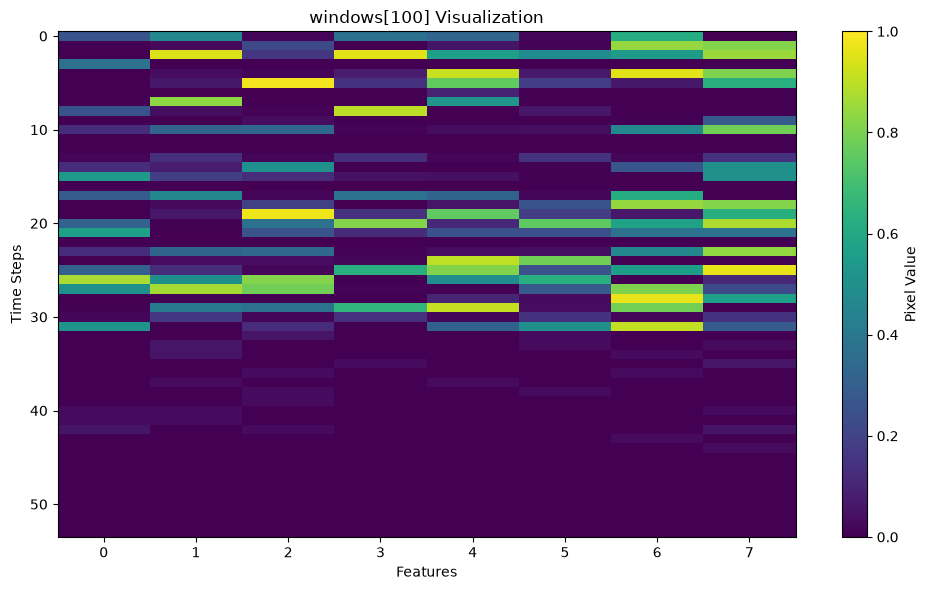

In [15]:
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt

# Display windows[100] as an image
plt.figure(figsize=(10, 6))
plt.imshow(windows[100], cmap='viridis', aspect='auto', norm=Normalize(vmin=windows[0].min(), vmax=windows[0].max()))
plt.colorbar(label='Pixel Value')
plt.xlabel('Features')
plt.ylabel('Time Steps')
plt.title('windows[100] Visualization')
plt.tight_layout()
plt.show()

In [16]:
import tensorflow as tf
import tensorflow as tf

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(54, 8, 1)))
#model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
epochs = 5

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(windows, attack_onehot, epochs=epochs, 
          batch_size=2000, 
          validation_split=0.2,
          callbacks=[early_stop])
          
print(mod)

Epoch 1/5
1157/1157 ━━━━━━━━━━━━━━━━━━━━ 274s 235ms/step - accuracy: 0.9176 - loss: 0.1999 - val_accuracy: 0.9879 - val_loss: 0.0363
Epoch 2/5
1157/1157 ━━━━━━━━━━━━━━━━━━━━ 271s 234ms/step - accuracy: 0.9869 - loss: 0.0376 - val_accuracy: 0.9736 - val_loss: 0.0699
Epoch 3/5
1157/1157 ━━━━━━━━━━━━━━━━━━━━ 274s 237ms/step - accuracy: 0.9925 - loss: 0.0215 - val_accuracy: 0.9912 - val_loss: 0.0239
Epoch 4/5
1157/1157 ━━━━━━━━━━━━━━━━━━━━ 266s 230ms/step - accuracy: 0.9948 - loss: 0.0150 - val_accuracy: 0.9950 - val_loss: 0.0139
Epoch 5/5
1157/1157 ━━━━━━━━━━━━━━━━━━━━ 266s 230ms/step - accuracy: 0.9960 - loss: 0.0115 - val_accuracy: 0.9925 - val_loss: 0.0215


In [18]:
conv1 = model.layers[0]
conv2 = model.layers[1]
dense1 = model.layers[3]
dense2 = model.layers[4]

W_conv1, b_conv1 = conv1.get_weights()
W_conv2, b_conv2 = conv2.get_weights()
W_dense1, b_dense1 = dense1.get_weights()
W_dense2, b_dense2 = dense2.get_weights()

np.savez_compressed(
        "w_data_for_snn.npz",
        W_conv1=W_conv1,
        b_conv1=b_conv1,
        W_conv2=W_conv2,
        b_conv2=b_conv2,
        W_dense1=W_dense1,
        b_dense1=b_dense1,
        W_dense2=W_dense2,
        b_dense2=b_dense2,
    )

In [19]:
loss, accuracy = model.evaluate(windows_test, attack_onehot_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0240
Test accuracy: 0.9916


In [20]:
label_map = np.array(['R', 'T'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(windows_test))
print(recovered_labels[:20])

22569/22569 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


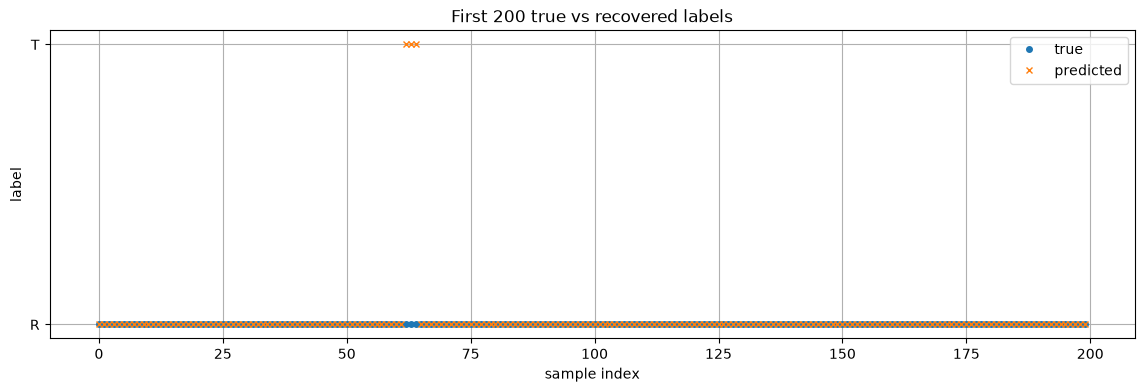

In [21]:
true_labels = np.array(onehot_to_labels(attack_onehot_test))
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

# Predictions
y_pred_probs = model.predict(windows_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(attack_onehot_test)

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
weighted_precision = precision_score(
    y_true, y_pred, average="weighted", zero_division=0
)
weighted_recall = recall_score(
    y_true, y_pred, average="weighted", zero_division=0
)
weighted_f1 = f1_score(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {weighted_precision:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")
print(f"Weighted F1 score: {weighted_f1:.4f}")
print()

# Classification report
print("Classification report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=label_map,
        target_names=label_map,
        zero_division=0,
        digits=2,        # Matches the example formatting
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=label_map)

print("Confusion matrix:")
print(pd.DataFrame(cm, index=label_map, columns=label_map))
print()

# Calculate FPR and FNR
tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(
    fps,
    fps + tns,
    out=np.zeros_like(fps, dtype=float),
    where=(fps + tns) != 0,
)

fnr = np.divide(
    fns,
    fns + tps,
    out=np.zeros_like(fns, dtype=float),
    where=(fns + tps) != 0,
)

print("False positive rate per class:")
for label, rate in zip(label_map, fpr):
    print(f"  {label}: {rate:.4f}")

print()
print("False negative rate per class:")
for label, rate in zip(label_map, fnr):
    print(f"  {label}: {rate:.4f}")

22569/22569 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step
Accuracy: 0.9917
Weighted precision: 0.9929
Weighted recall: 0.9917
Weighted F1 score: 0.9921

Classification report:
              precision    recall  f1-score   support

           R       1.00      0.99      1.00    703361
           T       0.78      0.95      0.86     18835

    accuracy                           0.99    722196
   macro avg       0.89      0.97      0.93    722196
weighted avg       0.99      0.99      0.99    722196

Confusion matrix:
        R      T
R  698278   5083
T     924  17911

False positive rate per class:
  R: 0.0491
  T: 0.0072

False negative rate per class:
  R: 0.0072
  T: 0.0491


In [ ]:
model.save("ROAD_model_2.h5")
print("Saved model to ROAD_model_2.h5")

Saved model to ROAD_model_2.h5


In [ ]:
"""import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model_2.h5"))
print("Saved model to saved_models/HCRL_model_2.h5")"""
exit()
hello()

NameError: name 'hello' is not defined

: 

In [ ]:
import numpy as np

windows = np.expand_dims(windows, axis=-1)
windows_test = np.expand_dims(windows_test, axis=-1)

def representative_dataset():
    for i in range(100):
        yield [windows[i:i+1].astype(np.float32)]

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("cnn_int8_2.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
interpreter = tf.lite.Interpreter(
    model_path="cnn_int8_2.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
sample = windows[0:1].astype(np.float32)

scale, zero_point = input_details[0]["quantization"]

sample_int8 = (sample / scale + zero_point).astype(np.int8)

In [ ]:
import tensorflow as tf
import numpy as np
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

# ----------------------------
# Load TFLite model
# ----------------------------

interpreter = tf.lite.Interpreter(model_path="cnn_int8_2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero = input_details[0]["quantization"]
output_scale, output_zero = output_details[0]["quantization"]

# ----------------------------
# Run inference
# ----------------------------

predictions = []

start = time.perf_counter()

for sample in windows_test:

    sample = np.expand_dims(sample, axis=0).astype(np.float32)

    # Quantize input if needed
    if input_details[0]["dtype"] == np.int8:
        sample = (sample / input_scale + input_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    # Dequantize output
    if output_details[0]["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero) * output_scale

    predictions.append(np.argmax(output))

end = time.perf_counter()

print(f"Average inference time: {(end-start)/len(windows_test)*1000:.3f} ms")

predictions = np.array(predictions)

# ----------------------------
# Convert one-hot labels
# ----------------------------

y_true = np.argmax(attack_onehot_test, axis=1)

# ----------------------------
# Accuracy
# ----------------------------

accuracy = accuracy_score(y_true, predictions)

print(f"\nTest accuracy: {accuracy:.4f}")

# ----------------------------
# Classification report
# ----------------------------

target_names = ["R","D","F","S"]

print("\nClassification report:")
print(
    classification_report(
        y_true,
        predictions,
        target_names=target_names,
        digits=4
    )
)

# ----------------------------
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(y_true, predictions)

print("\nConfusion matrix:")
print("\tR\tD\tF\tS")
print(cm)

# ----------------------------
# Per-class metrics
# ----------------------------

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    predictions
)

for i, cls in enumerate(target_names):

    FP = cm[:, i].sum() - cm[i, i]
    FN = cm[i, :].sum() - cm[i, i]
    TP = cm[i, i]
    TN = cm.sum() - (TP + FP + FN)

    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)

    print(
        f"{cls}: "
        f"precision={precision[i]:.4f}, "
        f"recall={recall[i]:.4f}, "
        f"f1={f1[i]:.4f}, "
        f"false positive rate={fpr:.4f}, "
        f"false negative rate={fnr:.4f}"
    )

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\CNN\saved_models\cnn_int8_2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model loaded successfully")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")